C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\momo\AppData\Local\Temp\ipykernel_17884\155108887.py:26: UserWarning: Glyph 20540 (\N{CJK UNIFIE

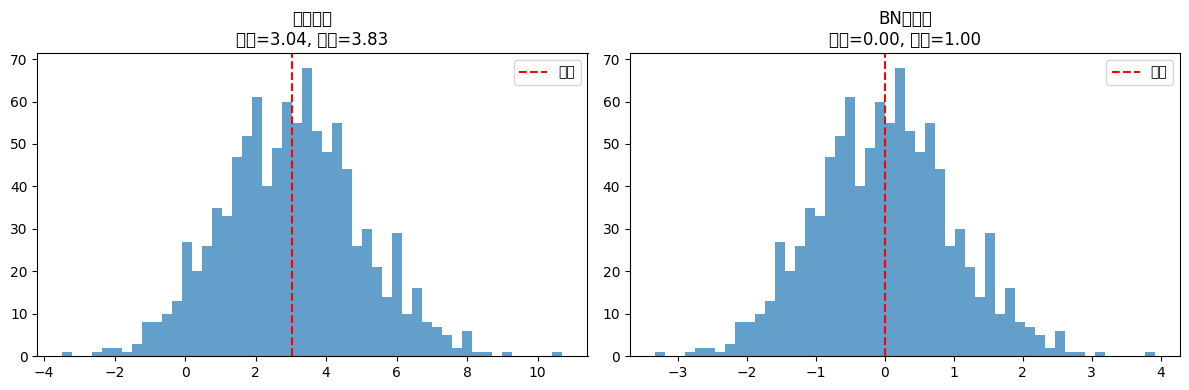

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.randn(1000, 1) * 2 + 3  # 强行更改均值为3，方差为4
mean = np.mean(data)
var = np.var(data)
normalized = (data - mean) / np.sqrt(var + 1e-5)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data, bins=50, alpha=0.7)
axes[0].set_title(f'原始数据\n均值={mean:.2f}, 方差={var:.2f}')
axes[0].axvline(mean, color='r', linestyle='--', label='均值')
axes[0].legend()

axes[1].hist(normalized, bins=50, alpha=0.7)
axes[1].set_title(f'BN处理后\n均值={np.mean(normalized):.2f}, 方差={np.var(normalized):.2f}')
axes[1].axvline(0, color='r', linestyle='--', label='均值')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ==================== 1. 批量归一化 (Batch Normalization) 层实现 ====================
# 这一部分是 PyTorch 内部已经实现的 nn.BatchNorm2d / nn.BatchNorm1d，
# 我们只是展示它的工作原理和如何使用。

# 演示 BatchNorm2d (常用于卷积层后)
class BN2D_Demo(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        """
        初始化 Batch Normalization 2D 层
        :param num_features: 输入特征的数量（例如，卷积层的输出通道数）
        :param eps: 分母中添加的一个小值，用于数值稳定性，防止除以零
        :param momentum: 用于运行平均值和方差的滑动平均的动量因子
        """
        super(BN2D_Demo, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        # 可学习的参数：gamma (scale) 和 beta (shift)
        # gamma: 缩放因子，允许网络学习恢复被 BN 破坏的表示能力
        # beta: 偏移因子，允许网络学习恢复被 BN 破坏的表示能力
        self.gamma = nn.Parameter(torch.ones(num_features)) # 初始化为全1
        self.beta = nn.Parameter(torch.zeros(num_features)) # 初始化为全0

        # 非可学习的参数：运行时的全局均值和方差
        # 在训练时，我们会用当前批次的均值和方差来更新它们
        # 在推理（测试）时，会使用它们来进行归一化
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

    def forward(self, x):
        """
        前向传播
        :param x: 输入张量，形状为 (N, C, H, W)
                  N: batch size (批次大小)
                  C: num_features (通道数)
                  H: height (高度)
                  W: width (宽度)
        :return: 归一化后的输出张量
        """
        # 检查输入形状是否正确
        if x.dim() != 4:
            raise ValueError("BatchNorm2D 期望输入是4维张量 (N, C, H, W)")
        if x.shape[1] != self.num_features:
             raise ValueError(f"输入通道数 {x.shape[1]} 与 BN 层期望的 {self.num_features} 不匹配")

        # 1. 判断当前是训练模式还是评估模式
        if self.training:
            # 训练模式：
            #   a. 计算当前批次的均值和方差
            #      - mean/var 需要按通道维度（C）计算，所以 keepdim=True 保留维度以便广播
            #      - mean() 和 var() 默认计算所有元素的均值和方差，所以要指定 dim=[0, 2, 3]
            #      - dim=[0, 2, 3] 表示在 batch, height, width 这三个维度上计算均值和方差
            mean = x.mean(dim=[0, 2, 3], keepdim=True)
            var = x.var(dim=[0, 2, 3], keepdim=True, unbiased=False) # unbiased=False 使用批次方差，与PyTorch默认一致

            #   b. 更新运行时的全局均值和方差
            #      - 使用 momentum 进行滑动平均更新
            #      - running_mean = momentum * batch_mean + (1 - momentum) * running_mean
            #      - running_var = momentum * batch_var + (1 - momentum) * running_var
            #      - .data 用于直接修改张量值，避免梯度跟踪
            self.running_mean = self.momentum * mean.data + (1 - self.momentum) * self.running_mean.data
            self.running_var = self.momentum * var.data + (1 - self.momentum) * self.running_var.data

            #   c. 对当前批次数据进行归一化
            #      - x_norm = (x - mean) / sqrt(var + eps)
            x_norm = (x - mean) / torch.sqrt(var + self.eps)

            #   d. 应用可学习的缩放 (gamma) 和偏移 (beta)
            #      - gamma 和 beta 的形状是 (1, C, 1, 1)，可以广播到 x_norm 的形状
            out = self.gamma.view(1, self.num_features, 1, 1) * x_norm + self.beta.view(1, self.num_features, 1, 1)

        else:
            # 评估（推理/测试）模式：
            #   - 使用预先计算好的运行时的全局均值和方差
            mean = self.running_mean.view(1, self.num_features, 1, 1)
            var = self.running_var.view(1, self.num_features, 1, 1)

            #   - 对输入数据进行归一化
            x_norm = (x - mean) / torch.sqrt(var + self.eps)

            #   - 应用可学习的缩放 (gamma) 和偏移 (beta)
            out = self.gamma.view(1, self.num_features, 1, 1) * x_norm + self.beta.view(1, self.num_features, 1, 1)

        return out

# 演示 BatchNorm1d (常用于全连接层后)
class BN1D_Demo(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        """
        初始化 Batch Normalization 1D 层
        :param num_features: 输入特征的数量（例如，全连接层的输出维度）
        :param eps: 分母中添加的一个小值，用于数值稳定性
        :param momentum: 用于运行平均值和方差的滑动平均的动量因子
        """
        super(BN1D_Demo, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

    def forward(self, x):
        """
        前向传播
        :param x: 输入张量，形状为 (N, C) 或 (N, L, C)
                  N: batch size (批次大小)
                  C: num_features (特征维度)
                  L: sequence length (序列长度，如果输入是3D的)
        :return: 归一化后的输出张量
        """
        # 检查输入形状
        if x.dim() < 2 or x.dim() > 3:
            raise ValueError("BatchNorm1D 期望输入是2D (N, C) 或 3D (N, L, C) 张量")
        if x.shape[-1] != self.num_features: # 检查最后一个维度是否是特征数
             raise ValueError(f"输入特征数 {x.shape[-1]} 与 BN 层期望的 {self.num_features} 不匹配")

        if self.training:
            # 训练模式
            # 计算均值和方差，按最后一个维度（特征维度 C）计算
            # 如果是3D输入 (N, L, C)，需要将 N 和 L 维度合并起来计算批次均值
            if x.dim() == 3:
                # reshaping input to (N*L, C) for easier mean/var calculation
                x_reshaped = x.view(-1, self.num_features)
                mean = x_reshaped.mean(dim=0, keepdim=True)
                var = x_reshaped.var(dim=0, keepdim=True, unbiased=False)
                
                # 更新 running_mean 和 running_var
                self.running_mean = self.momentum * mean.data + (1 - self.momentum) * self.running_mean.data
                self.running_var = self.momentum * var.data + (1 - self.momentum) * self.running_var.data

                # 归一化
                x_norm = (x_reshaped - mean) / torch.sqrt(var + self.eps)
                # reshape back to original shape
                out = x_norm.view(x.shape) # 恢复原来的 N, L, C 形状

            else: # 2D input (N, C)
                mean = x.mean(dim=0, keepdim=True)
                var = x.var(dim=0, keepdim=True, unbiased=False)
                
                self.running_mean = self.momentum * mean.data + (1 - self.momentum) * self.running_mean.data
                self.running_var = self.momentum * var.data + (1 - self.momentum) * self.running_var.data

                x_norm = (x - mean) / torch.sqrt(var + self.eps)
                out = x_norm # 形状不变

            # 应用 gamma 和 beta
            # gamma 和 beta 的形状是 (C,)，可以自动广播到 out 的形状
            out = self.gamma * out + self.beta

        else:
            # 评估模式
            mean = self.running_mean.view(1, self.num_features)
            var = self.running_var.view(1, self.num_features)
            
            if x.dim() == 3:
                x_reshaped = x.view(-1, self.num_features)
                x_norm = (x_reshaped - mean) / torch.sqrt(var + self.eps)
                out = x_norm.view(x.shape)
            else: # 2D input
                x_norm = (x - mean) / torch.sqrt(var + self.eps)
                out = x_norm
                
            # 应用 gamma 和 beta
            out = self.gamma * out + self.beta
            
        return out

# ==================== 2. 使用 PyTorch 内置的 BatchNorm ====================
# 在实际应用中，我们几乎总是使用 PyTorch 提供的 nn.BatchNorm2d 或 nn.BatchNorm1d。
# 它们经过高度优化，并且已经处理了所有边缘情况。

# 示例：构建一个简单的卷积网络，并在其中使用 BatchNorm2d
class SimpleCNN_With_BN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN_With_BN, self).__init__()
        # 初始卷积层
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        # Batch Normalization 层，通道数为 64
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)

        # 第二个卷积层
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 最大池化

        # 全连接层之前的自适应平均池化，将特征图池化到 1x1
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 全连接层
        self.fc = nn.Linear(128, num_classes) # 输入特征数为 128 (来自 bn2 或 conv2 的输出通道数)

    def forward(self, x):
        # 输入形状: (N, 3, H, W)
        x = self.conv1(x)       # 输出: (N, 64, H, W)
        x = self.bn1(x)         # BN 输出: (N, 64, H, W)
        x = self.relu1(x)       # ReLU 输出: (N, 64, H, W)

        x = self.conv2(x)       # 输出: (N, 128, H, W)
        x = self.bn2(x)         # BN 输出: (N, 128, H, W)
        x = self.relu2(x)       # ReLU 输出: (N, 128, H, W)
        x = self.pool(x)        # 池化输出: (N, 128, H/2, W/2)

        x = self.avgpool(x)     # 输出: (N, 128, 1, 1)
        x = torch.flatten(x, 1) # 展平为: (N, 128)
        x = self.fc(x)          # 输出: (N, num_classes)
        return x

# ==================== 3. 演示如何使用和训练 ====================

if __name__ == "__main__":
    # 0. 设置设备
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 1. 准备数据 (这里用随机数据模拟)
    batch_size = 64
    input_channels = 3
    image_height = 32
    image_width = 32
    num_classes = 10

    # 模拟一个包含 BN2D 层的模型
    print("\n--- 演示 BatchNorm2d ---")
    dummy_input_conv = torch.randn(batch_size, input_channels, image_height, image_width)
    
    # 使用 PyTorch 内置的 BatchNorm2d
    model_bn2d_pytorch = SimpleCNN_With_BN(num_classes=num_classes).to(device)
    model_bn2d_pytorch.train() # 设置为训练模式
    output_pytorch = model_bn2d_pytorch(dummy_input_conv.to(device))
    print(f"PyTorch 内置 BatchNorm2d 输出形状: {output_pytorch.shape}")

    # 使用我们自己实现的 BatchNorm2d
    # 注意：这里直接用我们自己的 BN 类，不是集成在模型里，只是单独演示
    bn2d_custom = BN2D_Demo(num_features=input_channels).to(device) # 输入通道数3
    bn2d_custom.train() # 设置为训练模式
    dummy_input_custom = torch.randn(batch_size, input_channels, image_height, image_width)
    output_custom = bn2d_custom(dummy_input_custom)
    print(f"自定义 BatchNorm2d 输出形状: {output_custom.shape}")

    # 演示 BatchNorm1d (模拟全连接层输出)
    print("\n--- 演示 BatchNorm1d ---")
    dummy_input_fc = torch.randn(batch_size, 128) # 假设前面层输出 128 个特征
    
    # 使用 PyTorch 内置的 BatchNorm1d
    bn1d_pytorch = nn.BatchNorm1d(128).to(device)
    bn1d_pytorch.train()
    output_bn1d_pytorch = bn1d_pytorch(dummy_input_fc.to(device))
    print(f"PyTorch 内置 BatchNorm1d 输出形状: {output_bn1d_pytorch.shape}")
    
    # 使用我们自己实现的 BatchNorm1d
    bn1d_custom = BN1D_Demo(num_features=128).to(device)
    bn1d_custom.train()
    dummy_input_custom_1d = torch.randn(batch_size, 128)
    output_custom_1d = bn1d_custom(dummy_input_custom_1d)
    print(f"自定义 BatchNorm1d 输出形状: {output_custom_1d.shape}")

    # 演示 3D 输入的 BatchNorm1d (例如 LSTM/GRU 的输出)
    print("\n--- 演示 BatchNorm1d (3D input) ---")
    sequence_length = 50
    dummy_input_3d = torch.randn(batch_size, sequence_length, 128)
    bn1d_3d_custom = BN1D_Demo(num_features=128).to(device)
    bn1d_3d_custom.train()
    output_3d = bn1d_3d_custom(dummy_input_3d)
    print(f"自定义 BatchNorm1d (3D input) 输出形状: {output_3d.shape}")


    # 2. 演示训练过程 (使用我们上面定义的 SimpleCNN_With_BN)
    print("\n--- 模拟模型训练过程 ---")
    model = SimpleCNN_With_BN(num_classes=num_classes).to(device)

    # 损失函数
    criterion = nn.CrossEntropyLoss()

    # 优化器
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # 学习率调度器 (可选，但推荐)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1) # 每30个epoch学习率减半

    num_epochs = 3 # 演示只跑几轮

    # 伪造数据加载器 (实际训练需要CIFAR10等真实数据集)
    # 为了演示，我们只生成随机的输入和标签
    from torch.utils.data import TensorDataset, DataLoader
    
    # 模拟训练数据
    dummy_train_data = torch.randn(batch_size * 5, input_channels, image_height, image_width)
    dummy_train_labels = torch.randint(0, num_classes, (batch_size * 5,))
    train_dataset = TensorDataset(dummy_train_data, dummy_train_labels)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    # 模拟测试数据
    dummy_test_data = torch.randn(batch_size * 2, input_channels, image_height, image_width)
    dummy_test_labels = torch.randint(0, num_classes, (batch_size * 2,))
    test_dataset = TensorDataset(dummy_test_data, dummy_test_labels)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"模拟训练 {num_epochs} 个 Epoch...")
    for epoch in range(1, num_epochs + 1):
        # 训练模式
        model.train() # 必须调用 model.train() 来启用 BN 的训练模式（使用批次均值方差）
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # 使用tqdm显示进度条
        from tqdm import tqdm
        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')
        
        for i, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(device), labels.to(device)

            # 清零梯度
            optimizer.zero_grad()

            # 前向传播
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 反向传播与更新
            loss.backward()
            optimizer.step()

            # 统计损失和准确率
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{running_loss / (i + 1):.4f}',
                'Acc': f'{100. * correct_train / total_train:.2f}%'
            })
        
        train_accuracy = 100. * correct_train / total_train
        avg_train_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch}/{num_epochs}] 训练 - Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")

        # 更新学习率
        scheduler.step()

        # 测试模式
        model.eval() # 必须调用 model.eval() 来启用 BN 的评估模式（使用运行时的全局均值方差）
        correct_test = 0
        total_test = 0
        test_loss = 0.0
        
        with torch.no_grad(): # 在评估模式下，不需要计算梯度
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        test_accuracy = 100. * correct_test / total_test
        avg_test_loss = test_loss / len(test_loader)
        print(f"Epoch [{epoch}/{num_epochs}] 测试 - Loss: {avg_test_loss:.4f}, Accuracy: {test_accuracy:.2f}%")

    print("\n模拟训练过程结束。")
    # 实际应用中，你会在训练完成后保存模型:
    # torch.save(model.state_dict(), 'model_with_bn.pth')

使用设备: cuda

--- 演示 BatchNorm2d ---
PyTorch 内置 BatchNorm2d 输出形状: torch.Size([64, 10])


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!